# BenchMARL IQL on VMAS Simple Tag

This notebook uses **VMAS** for faster simulation throughput and trains **Independent Q-Learning (IQL)** with BenchMARL.

Compared to PettingZoo, VMAS runs many environments in parallel (optionally on GPU), which is usually much faster.


In [1]:
from pathlib import Path

import torch

from benchmarl.environments import VmasTask
from benchmarl.experiment import Experiment, ExperimentConfig
from benchmarl.algorithms.iql import IqlConfig
from benchmarl.models.mlp import MlpConfig

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda:0


In [2]:
# VMAS-accelerated training config
SEED = 0
MAX_STEPS = 100
N_CHASERS = 2
N_EVADERS = 1
N_OBSTACLES = 2

# Main speed lever: number of VMAS envs collected in parallel
NUM_ENVS = 64
FRAMES_PER_BATCH = NUM_ENVS * MAX_STEPS

N_ITERS = 200
TRAIN_BATCH_SIZE = 512
MEMORY_SIZE = 300_000

EVAL_EVERY_BATCHES = 20
CKPT_EVERY_BATCHES = 25
EVAL_INTERVAL_FRAMES = EVAL_EVERY_BATCHES * FRAMES_PER_BATCH
CHECKPOINT_INTERVAL_FRAMES = CKPT_EVERY_BATCHES * FRAMES_PER_BATCH

RUN_ROOT = Path("./benchmarl_runs/vmas_simple_tag_iql").resolve()
RUN_ROOT.mkdir(parents=True, exist_ok=True)

def patch_fields(obj, **kwargs):
    skipped = []
    for key, value in kwargs.items():
        if isinstance(obj, dict):
            if key in obj:
                obj[key] = value
            else:
                skipped.append(key)
        elif hasattr(obj, key):
            setattr(obj, key, value)
        else:
            skipped.append(key)
    return skipped

task_name = "SIMPLE_TAG" if hasattr(VmasTask, "SIMPLE_TAG") else "SIMPLE_ADVERSARY"
task_enum = getattr(VmasTask, task_name)
task = task_enum.get_from_yaml()
task_cfg = getattr(task, "config", task)

task_skipped = patch_fields(
    task_cfg,
    continuous_actions=False,
    max_steps=MAX_STEPS,
    num_good_agents=N_EVADERS,
    num_adversaries=N_CHASERS,
    num_landmarks=N_OBSTACLES,
)
if task_skipped:
    print("Task fields not found in this BenchMARL version:", task_skipped)
print("Task config after overrides:", task_cfg)

algo_config = IqlConfig.get_from_yaml()
model_config = MlpConfig.get_from_yaml()
exp_config = ExperimentConfig.get_from_yaml()

algo_skipped = patch_fields(
    algo_config,
    delay_value=True,
    loss_function="l2",
)
if algo_skipped:
    print("Algorithm fields not found:", algo_skipped)

exp_skipped = patch_fields(
    exp_config,
    train_device=device,
    sampling_device=device,
    buffer_device=device,
    prefer_continuous_actions=False,
    max_n_iters=N_ITERS,
    max_n_frames=None,
    off_policy_n_envs_per_worker=NUM_ENVS,
    off_policy_collected_frames_per_batch=FRAMES_PER_BATCH,
    off_policy_n_optimizer_steps=1,
    off_policy_train_batch_size=TRAIN_BATCH_SIZE,
    off_policy_memory_size=MEMORY_SIZE,
    off_policy_init_random_frames=max(2 * FRAMES_PER_BATCH, 2000),
    evaluation=True,
    evaluation_interval=EVAL_INTERVAL_FRAMES,
    evaluation_episodes=5,
    evaluation_deterministic_actions=True,
    checkpoint_interval=CHECKPOINT_INTERVAL_FRAMES,
    checkpoint_at_end=True,
    save_folder=str(RUN_ROOT),
    loggers=["csv"],
    project_name="benchmarl_vmas_simple_tag_iql",
    create_json=True,
)
if exp_skipped:
    print("Experiment fields not found:", exp_skipped)

experiment = Experiment(
    task=task,
    algorithm_config=algo_config,
    model_config=model_config,
    critic_model_config=model_config,
    seed=SEED,
    config=exp_config,
)

print("Task enum:", task_name)
print("NUM_ENVS:", NUM_ENVS, "FRAMES_PER_BATCH:", FRAMES_PER_BATCH)
print("Run folder:", RUN_ROOT)
print("evaluation_interval (frames):", EVAL_INTERVAL_FRAMES)
print("checkpoint_interval (frames):", CHECKPOINT_INTERVAL_FRAMES)


Task fields not found in this BenchMARL version: ['continuous_actions']
Task config after overrides: {'max_steps': 100, 'num_good_agents': 1, 'num_adversaries': 2, 'num_landmarks': 2, 'shape_agent_rew': False, 'shape_adversary_rew': False, 'agents_share_rew': False, 'adversaries_share_rew': True, 'observe_same_team': True, 'observe_pos': True, 'observe_vel': True, 'bound': 1.0, 'respawn_at_catch': False}


/vol/bitbucket/jhl323/fypenv/lib/python3.12/site-packages/torchrl/collectors/_base.py:1045: DeprecationWarning: SyncDataCollector has been deprecated and will be removed in v0.13. Please use Collector instead.
  warnings.warn(


Task enum: SIMPLE_TAG
NUM_ENVS: 64 FRAMES_PER_BATCH: 6400
Run folder: /homes/jhl323/SRE-DQN/discrete_action_space/n_player/benchmarl_runs/vmas_simple_tag_iql
evaluation_interval (frames): 128000
checkpoint_interval (frames): 160000


In [3]:
# Train
try:
    experiment.run()
finally:
    experiment.close()

print("Training complete.")


  0%|          | 0/200 [00:00<?, ?it/s]

2026-02-11 23:57:47,232 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([300000]) shape [END]
2026-02-11 23:57:48,988 [torchrl][INFO]    Initialized LazyTensorStorage with torch.Size([300000]) shape [END]


/vol/bitbucket/jhl323/fypenv/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
mean return = 0.0: 100%|██████████| 200/200 [11:38<00:00,  3.49s/it]

Training complete.


In [4]:
# Inspect generated artifacts
all_files = sorted(RUN_ROOT.rglob("*"))
print("Total artifacts:", len(all_files))
for p in all_files[:60]:
    print(p.relative_to(RUN_ROOT))


Total artifacts: 58
iql_simple_tag_mlp__7c489347_26_02_11-23_56_22
iql_simple_tag_mlp__7c489347_26_02_11-23_56_22/config.pkl
iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18
iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18/checkpoints
iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18/checkpoints/checkpoint_1120000.pt
iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18/checkpoints/checkpoint_1280000.pt
iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18/config.pkl
iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18/iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18
iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18/iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18/scalars
iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18/iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18/scalars/collection_adversary_reward_episode_reward_max.csv
iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18/iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18/scalars/collection_adversary_reward_episode_reward_mean.csv
iql_simple_tag_mlp__ad886ab5_26_02_11-23_57_18

CSV files found: 34


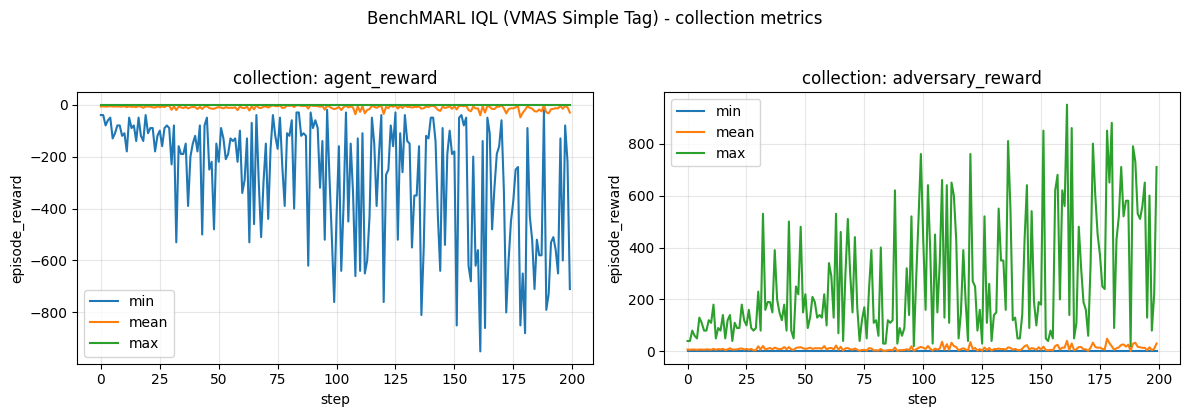

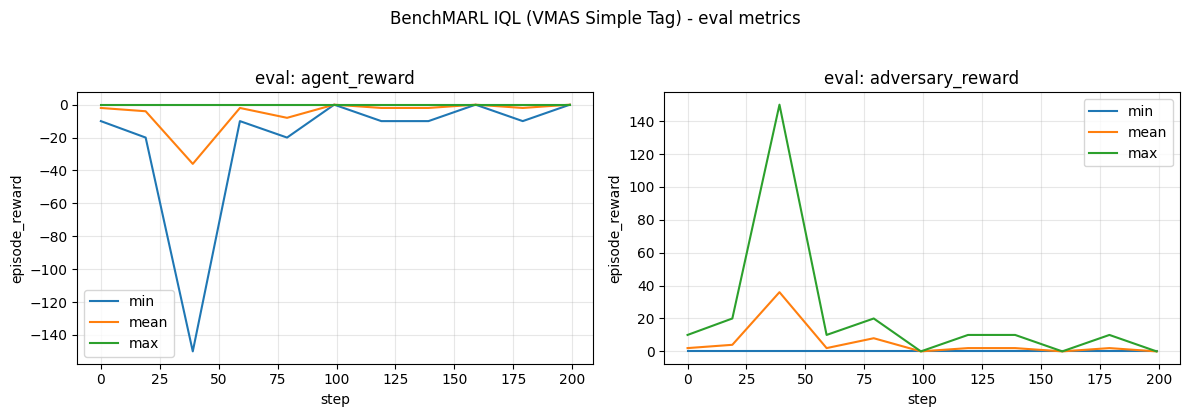

In [9]:
# Plot reward metrics in grouped subplots (agent vs adversary only)
import re
import matplotlib.pyplot as plt
import pandas as pd

csv_files = sorted(RUN_ROOT.rglob("*.csv"), key=lambda p: p.stat().st_mtime)
print("CSV files found:", len(csv_files))

pattern = re.compile(
    r"^(collection|eval)_(adversary_reward|agent_reward|reward)_episode_reward_(min|mean|max)$"
)

metrics = {}
for p in csv_files:
    m = pattern.match(p.stem)
    if not m:
        continue

    phase, group, stat = m.groups()
    df = pd.read_csv(p, header=None, names=["step", "value"])
    if df.empty:
        continue

    metrics.setdefault((phase, group), {})[stat] = df

if not metrics:
    print("No matching reward metric CSV files found.")
else:
    phases = sorted({k[0] for k in metrics.keys()})
    # Exclude aggregate "reward" subplot (it is flat zero in this zero-sum setup)
    groups = ["agent_reward", "adversary_reward"]
    stats_order = ["min", "mean", "max"]

    for phase in phases:
        present_groups = [g for g in groups if (phase, g) in metrics]
        if not present_groups:
            continue

        n = len(present_groups)
        fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), squeeze=False)
        axes = axes[0]

        for i, group in enumerate(present_groups):
            ax = axes[i]
            stat_map = metrics[(phase, group)]

            for stat in stats_order:
                if stat not in stat_map:
                    continue
                df = stat_map[stat]
                ax.plot(df["step"], df["value"], label=stat)

            ax.set_title(f"{phase}: {group}")
            ax.set_xlabel("step")
            ax.set_ylabel("episode_reward")
            ax.grid(alpha=0.3)
            ax.legend()

        fig.suptitle(f"BenchMARL IQL (VMAS Simple Tag) - {phase} metrics", y=1.03)
        plt.tight_layout()
        plt.show()



In [ ]:
# Optional: evaluate latest checkpoint
checkpoints = sorted(RUN_ROOT.rglob("checkpoint_*.pt"), key=lambda p: p.stat().st_mtime)
if not checkpoints:
    print("No checkpoint files found.")
else:
    latest_ckpt = checkpoints[-1]
    print("Evaluating checkpoint:", latest_ckpt)
    eval_exp = Experiment.reload_from_file(str(latest_ckpt))
    try:
        eval_exp.evaluate()
    finally:
        eval_exp.close()
    print("Evaluation complete.")


In [11]:
# Visualize trained agents playing (deterministic policy rollout)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
from torchrl.envs.utils import ExplorationType, set_exploration_type


def _to_hwc_uint8(frame):
    if hasattr(frame, "detach"):
        frame = frame.detach().cpu().numpy()
    frame = np.asarray(frame)

    # If batched, take the first item.
    if frame.ndim == 4:
        frame = frame[0]

    # Convert CHW -> HWC when needed.
    if frame.ndim == 3 and frame.shape[0] in (1, 3, 4) and frame.shape[-1] not in (1, 3, 4):
        frame = np.transpose(frame, (1, 2, 0))

    if frame.dtype != np.uint8:
        frame = np.clip(frame, 0, 255).astype(np.uint8)
    return frame


def render_trained_rollout(exp, max_steps=None):
    frames = []

    def callback(env, td):
        frames.append(exp.task.render_callback(exp, env, td))

    rollout_steps = max_steps or exp.max_steps
    with set_exploration_type(ExplorationType.DETERMINISTIC):
        _ = exp.test_env.rollout(
            max_steps=rollout_steps,
            policy=exp.policy,
            callback=callback,
            auto_cast_to_device=True,
            break_when_any_done=True,
        )

    return frames


# Prefer current in-memory experiment; fallback to latest checkpoint.
viz_exp = None
close_viz_exp = False

if "experiment" in globals() and getattr(experiment, "policy", None) is not None:
    viz_exp = experiment
    print("Using in-memory experiment object.")
else:
    checkpoints = sorted(RUN_ROOT.rglob("checkpoint_*.pt"), key=lambda p: p.stat().st_mtime)
    if not checkpoints:
        raise RuntimeError("No in-memory experiment and no checkpoint found.")

    latest_ckpt = checkpoints[-1]
    print("Reloading checkpoint:", latest_ckpt)
    viz_exp = Experiment.reload_from_file(str(latest_ckpt))
    close_viz_exp = True

try:
    frames = render_trained_rollout(viz_exp)
    print("Captured frames:", len(frames))

    if not frames:
        raise RuntimeError("No frames captured. Check environment rendering support.")

    first = _to_hwc_uint8(frames[0])
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(first)
    ax.set_title("VMAS Simple Tag - Trained IQL Policy")
    ax.axis("off")

    def _update(i):
        im.set_data(_to_hwc_uint8(frames[i]))
        return [im]

    ani = animation.FuncAnimation(
        fig,
        _update,
        frames=len(frames),
        interval=60,
        blit=True,
    )

    plt.close(fig)
    display(HTML(ani.to_jshtml()))
finally:
    if close_viz_exp and viz_exp is not None:
        viz_exp.close()



Using in-memory experiment object.
Captured frames: 99


## Notes on VMAS speed
- Increase `NUM_ENVS` to improve throughput, until you hit memory limits.
- Keep `sampling_device` and `train_device` on GPU for best speed.
- If you hit OOM, reduce `NUM_ENVS`, `TRAIN_BATCH_SIZE`, or `MEMORY_SIZE`.

## CLI equivalent
```bash
python -m benchmarl.run \
  algorithm=iql \
  task=vmas/simple_tag \
  experiment.prefer_continuous_actions=false \
  experiment.off_policy_n_envs_per_worker=64 \
  experiment.off_policy_collected_frames_per_batch=6400 \
  experiment.off_policy_train_batch_size=512
```
